# Executive Summary: Predictive Analysis and Intelligent Forecasting

## 1. Project Overview
The objective of this project is to develop a robust forecasting system for monthly financial movements. By combining **Time Series Forecasting (Prophet)** with **Market Basket Analysis (Association Rules)**, we aim to move beyond simple historical trends and incorporate external "signals" or behavioral patterns that influence total spending.

## 2. Methodology: The Hybrid Approach

The work was carried out in four main stages:

### A. Data Preprocessing and Categorization
* **Payment Type Logic:** Transactions were strictly classified into **Credits** (income) and **Debits** (expenses) using explicit payment status, ensuring the model distinguishes between cash inflows and outflows regardless of the mathematical sign in the raw data.
* **Date Normalization:** Data was aggregated into a **Monthly Time Series** to reduce daily noise and focus on macro-financial trends.

### B. Intelligent Feature Engineering (Association Rules)
* Instead of manually choosing regressors, we applied **Affinity Analysis** to discover hidden relationships between spending categories.
* We identified categories that act as **temporal leads** (e.g., spending in one category last month that predicts behavior in the current month) using the `_prev_month` and `_current_month` logic.

### C. Predictive Modeling (Prophet)
* **Baseline Model:** A control model relying solely on historical seasonality and linear growth.
* **Extended Model:** An advanced version using the discovered association rules as **External Regressors**. This model attempts to use the volume of specific categories (like Restaurants or Fast Food) to "explain" fluctuations in the total monthly balance.



### D. Automated Regressor Optimization
* **Zero-Value Cleanup:** An automated filter was implemented to detect and remove "dead" regressors (columns with no data), ensuring the model only trains on active financial signals.
* **Statistical Evaluation:** We used **RMSE** (Root Mean Square Error) and **MAPE** (Mean Absolute Percentage Error) to rigorously compare if adding behavioral rules actually improves the accuracy of the forecast.

---

## 3. Current Status
The framework is fully functional. We have successfully automated the pipeline from raw transaction data to a comparative forecast. While the current signals show a strong baseline, the infrastructure is now ready to incorporate higher-volume "heavy" regressors that can significantly improve predictive precision.

In [70]:
# Importing the necessary libraries for analysis
import numpy as np
import pandas as pd
import json
# Data Visualization libraries
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
#Imporing libraries to avoid warnings
import warnings
import gc
import ijson

In [71]:
# Applying the important settings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# Download latest version
path = kagglehub.dataset_download("computingvictor/transactions-fraud-datasets")

print("Path to dataset files:", path)

import os
os.listdir(path)

Path to dataset files: /home/jango/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1


['train_fraud_labels.json',
 'users_data.csv',
 'cards_data.csv',
 'mcc_codes.json',
 'transactions_data.csv']

# Importing the data

## Reading the CSV files

In [72]:
import pandas as pd
import numpy as np

# Configuración
chunksize = 200_000
frac_users = 0.073 # Seleccionamos el 5% de los usuarios (ajusta según memoria disponible)


print("1. Obteniendo lista única de clientes...")
# Paso 1: Leer solo la columna de IDs para hacer el sorteo (muy rápido y ligero en RAM)
all_clients_ids = pd.read_csv(
    f"{path}/transactions_data.csv", 
    usecols=['client_id']
).drop_duplicates()['client_id']

# Paso 2: Seleccionar una muestra aleatoria de clientes
selected_clients = np.random.choice(
    all_clients_ids, 
    size=int(len(all_clients_ids) * frac_users), 
    replace=False
)
print(f"   -> Clientes seleccionados: {len(selected_clients)} (de {len(all_clients_ids)})")

# Convertir a set para búsqueda O(1) ultra rápida en el bucle
selected_clients_set = set(selected_clients)

# Paso 3: Cargar transacciones SOLO de esos clientes
print("2. Cargando transacciones de los clientes seleccionados...")
samples = []

for chunk in pd.read_csv(f"{path}/transactions_data.csv", chunksize=chunksize):
    # Filtramos antes de procesar nada más
    chunk_filtered = chunk[chunk['client_id'].isin(selected_clients_set)].copy()
    
    if not chunk_filtered.empty:
        # Procesamiento de fechas dentro del chunk para ahorrar memoria después
        chunk_filtered['date'] = pd.to_datetime(chunk_filtered['date'], errors='coerce')
        samples.append(chunk_filtered)

# Unir todo
trans = pd.concat(samples, ignore_index=True)
print(f"   -> Transacciones cargadas: {trans.shape[0]}")

# -------------------------------
# 2. Limpieza y Trimestres Completos
# -------------------------------

# Eliminar fechas nulas
trans = trans.dropna(subset=['date'])

# Crear columna trimestre
trans['quarter'] = trans['date'].dt.to_period('Q')

# Lógica de Trimestres Completos (evitar caídas artificiales al inicio/fin)
# Contamos cuántos meses únicos hay en cada trimestre EN EL DATASET FILTRADO
months_per_quarter = trans.assign(month=trans['date'].dt.to_period('M')).groupby('quarter')['month'].nunique()

# Solo nos quedamos con trimestres que tengan datos de los 3 meses (enero, feb, marzo, etc.)
complete_quarters = months_per_quarter[months_per_quarter == 3].index

# Filtramos
trans = trans[trans['quarter'].isin(complete_quarters)].copy()

print(f"   -> Transacciones finales (Trimestres Completos): {trans.shape}")
print(f"   -> Rango de fechas: {trans['date'].min()} a {trans['date'].max()}")

# -------------------------------
# 3. Cargar Usuarios y Tarjetas asociados
# -------------------------------
print("3. Cargando metadatos de usuarios y tarjetas...")

# Obtenemos los IDs que realmente quedaron en las transacciones finales
final_client_ids = trans['client_id'].unique()
final_card_ids = trans['card_id'].unique()

# Cargamos usuarios y tarjetas filtrando por los que existen en la muestra
users = pd.read_csv(f"{path}/users_data.csv").query("id in @final_client_ids")
cards = pd.read_csv(f"{path}/cards_data.csv").query("id in @final_card_ids")

print("Proceso completado.")
print(trans.head())

1. Obteniendo lista única de clientes...
   -> Clientes seleccionados: 88 (de 1219)
2. Cargando transacciones de los clientes seleccionados...
   -> Transacciones cargadas: 884616
   -> Transacciones finales (Trimestres Completos): (876921, 13)
   -> Rango de fechas: 2010-01-01 00:02:00 a 2019-09-30 23:14:00
3. Cargando metadatos de usuarios y tarjetas...
Proceso completado.
        id                date  client_id  card_id   amount  \
0  7475329 2010-01-01 00:02:00       1129      102   $80.00   
1  7475345 2010-01-01 00:32:00       1129     5492  $100.00   
2  7475360 2010-01-01 00:49:00        652     4293    $2.40   
3  7475364 2010-01-01 00:57:00       1201       16    $2.95   
4  7475373 2010-01-01 01:11:00       1642     4281    $3.96   

            use_chip  merchant_id  merchant_city merchant_state      zip  \
0  Swipe Transaction        27092          Vista             CA  92084.0   
1  Swipe Transaction        27092          Vista             CA  92084.0   
2  Swipe Transa

In [73]:
needed_ids = set(trans['id'].astype(int))

with open(f"{path}/mcc_codes.json", "r") as file:
    codes = json.load(file)

fraud = {}

with open(f"{path}/train_fraud_labels.json", "r") as f:
    for k, v in ijson.kvitems(f, "target"):
        k_int = int(k)
        if k_int in needed_ids:
            fraud[k_int] = v

gc.collect()

51465

## Reading and Manipulating the JSON files 

In [74]:
df1 = pd.DataFrame(
    fraud.items(),
    columns=["id", "Status"]
)

df1.head(3)

,id,Status
0,10649266,No
1,12478022,No
2,17126661,No


In [75]:
code = list(codes.keys())
name = list(codes.values())

df2 = pd.DataFrame({'mcc': code, 'Name': name})
df2.head(3)

,mcc,Name
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"


# Making the datasets ready for analysis

##  Cards data

In [76]:
cards.head(3)

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
27,5559,1116,Mastercard,Debit,5341049613275152,09/2021,396,YES,2,$26546,11/2009,2009,No
28,4905,1116,Mastercard,Debit,5668831527649353,01/2021,356,YES,1,$23253,09/2017,2017,No
29,79,1116,Visa,Credit,4400056931148232,02/2021,497,YES,1,$16100,01/2005,2014,No


In [77]:
cards.shape

(299, 13)

In [78]:
# Checking for any duplicated or missing values
print("Total Duplicated values found: ", cards.duplicated().sum())

print("Count of null values in each column are as follows: \n", cards.isnull().sum())

Total Duplicated values found:  0
Count of null values in each column are as follows: 
 id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64


Result : No missing or duplicated values were found in the data.

In [79]:
# Checking if correct datatypes are assigned to the columns

nuuniq = []
dtyp = []
uuniq = []

for col in cards.columns:
    nuuniq.append(cards[col].nunique())
    dtyp.append(cards[col].dtype)
    uuniq.append(cards[col].unique()[0])

result = pd.DataFrame({"Column Name": cards.columns, 'Count of Unique values': nuuniq, 'Assigned Datatype': dtyp, 'Value': uuniq})
result

,Column Name,Count of Unique values,Assigned Datatype,Value
0,id,299,int64,5559
1,client_id,88,int64,1116
2,card_brand,4,object,Mastercard
3,card_type,3,object,Debit
4,card_number,299,int64,5341049613275152
5,expires,106,object,09/2021
6,cvv,261,int64,396
7,has_chip,2,object,YES
8,num_cards_issued,3,int64,2
9,credit_limit,272,object,$26546


Considerations
- The column 'card_on_dark_web' has a constant value.

Issues Found:

1. The column 'Expires' and 'acct_open_date' is misassiged as object and should be datetime.
2. 'credit_limit' column is misassigned as object due to the presence of '$' symbol. It should be numeric.



In [80]:
# Fixing the issues found above.

# Converting the relevant columns to datetime
cards['expires'] = pd.to_datetime(cards['expires'])
cards['acct_open_date'] = pd.to_datetime(cards['acct_open_date'])

# Fixing the datatype misassignment for 'credit_limit' column
if 'credit_limit' in cards.columns:
    cards['credit_limit'] = (
        cards['credit_limit']
        .astype(str)
        .str.replace('[\$,]', '', regex=True)
        .astype(float)
    )

cards.rename(columns={'credit_limit': 'Credit_Limit'}, inplace=True)

# Rechecking the datatypes
nuuniq = []
dtyp = []
uuniq = []

for col in cards.columns:
    nuuniq.append(cards[col].nunique())
    dtyp.append(cards[col].dtype)
    uuniq.append(cards[col].unique()[0])

result = pd.DataFrame({"Column Name": cards.columns, 'Count of Unique values': nuuniq, 'Assigned Datatype': dtyp, 'Value': uuniq})
result

,Column Name,Count of Unique values,Assigned Datatype,Value
0,id,299,int64,5559
1,client_id,88,int64,1116
2,card_brand,4,object,Mastercard
3,card_type,3,object,Debit
4,card_number,299,int64,5341049613275152
5,expires,106,datetime64[ns],2021-09-01 00:00:00
6,cvv,261,int64,396
7,has_chip,2,object,YES
8,num_cards_issued,3,int64,2
9,Credit_Limit,272,float64,26546.0


The issues are resolved and the data is ready for analysis

## Users data

In [81]:
users.head(3)

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
8,1116,81,66,1938,7,Female,11 Spruce Avenue,40.32,-75.32,$26273,$42509,$2895,755,5
69,348,49,70,1970,7,Female,480 Seventh Lane,40.22,-74.76,$22747,$46377,$79980,719,3
108,1782,59,61,1961,2,Female,4254 Plum Lane,33.74,-117.99,$19438,$39633,$58586,777,3


**Problem 1:**
A study of the dataset reveals that one can work on customer segmentation to help understand different types of customers.

**Problem 2:**
When `users` data is merged with `card` data, one can work on the regression problem of predicting credit limit for a customer based on the user's data.

In [82]:
# Checking if correct datatypes are assigned to the columns

nuuniq = []
dtyp = []
uuniq = []

for col in users.columns:
    nuuniq.append(users[col].nunique())
    dtyp.append(users[col].dtype)
    uuniq.append(users[col].unique()[0])

result = pd.DataFrame({"Column Name": users.columns, 'Count of Unique values': nuuniq, 'Assigned Datatype': dtyp, 'Value': uuniq})
result

,Column Name,Count of Unique values,Assigned Datatype,Value
0,id,88,int64,1116
1,current_age,51,int64,81
2,retirement_age,16,int64,66
3,birth_year,48,int64,1938
4,birth_month,12,int64,7
5,gender,2,object,Female
6,address,88,object,11 Spruce Avenue
7,latitude,85,float64,40.32
8,longitude,86,float64,-75.32
9,per_capita_income,88,object,$26273


The columns 'per_capita_income', 'yearly_income' and 'total_debt' columns are assigned as object due to the presence of '$'. Resolving the issue and changing the datatype to numeric.

In [83]:
# Removing the '$' sign from the columns
users['per_capita_income'] = users['per_capita_income'].str.replace('$', '')
users['yearly_income'] = users['yearly_income'].str.replace('$', '')
users['total_debt'] = users['total_debt'].str.replace('$', '')

# Changing their datatype to numeric
users['per_capita_income'] = pd.to_numeric(users['per_capita_income'])
users['yearly_income'] = pd.to_numeric(users['yearly_income'])
users['total_debt'] = pd.to_numeric(users['total_debt'])

# Changning the names
users.rename(columns = {"per_capita_income": "per_capita_income($)", "yearly_income" : "yearly_income($)", "total_debt": "total_debt($)"}, inplace = True)

In [84]:
# Verifying the changes
users.dtypes

id                        int64
current_age               int64
retirement_age            int64
birth_year                int64
birth_month               int64
gender                   object
address                  object
latitude                float64
longitude               float64
per_capita_income($)      int64
yearly_income($)          int64
total_debt($)             int64
credit_score              int64
num_credit_cards          int64
dtype: object

The changes have been applied.

In [85]:
# Checking for any null values in the data

users.isnull().sum()

id                      0
current_age             0
retirement_age          0
birth_year              0
birth_month             0
gender                  0
address                 0
latitude                0
longitude               0
per_capita_income($)    0
yearly_income($)        0
total_debt($)           0
credit_score            0
num_credit_cards        0
dtype: int64

The code output clearly states that there is no null values present in the data suggesting that the data is ready for merger.

In [86]:
dfr = pd.merge(
    users,
    cards,
    left_on='id',       # id de cliente en users
    right_on='client_id',  # id de cliente en cards
    how='inner'
)
dfr.head(3)

,id_x,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income($),yearly_income($),total_debt($),credit_score,num_credit_cards,id_y,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,Credit_Limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,1116,81,66,1938,7,Female,11 Spruce Avenue,40.32,-75.32,26273,42509,2895,755,5,5559,1116,Mastercard,Debit,5341049613275152,2021-09-01,396,YES,2,26546.0,2009-11-01,2009,No
1,1116,81,66,1938,7,Female,11 Spruce Avenue,40.32,-75.32,26273,42509,2895,755,5,4905,1116,Mastercard,Debit,5668831527649353,2021-01-01,356,YES,1,23253.0,2017-09-01,2017,No
2,1116,81,66,1938,7,Female,11 Spruce Avenue,40.32,-75.32,26273,42509,2895,755,5,79,1116,Visa,Credit,4400056931148232,2021-02-01,497,YES,1,16100.0,2005-01-01,2014,No


## Codes data

In [87]:
df2.head(3)

,mcc,Name
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"


In [88]:
# Checking the datatype of the column on which the merger will take place
df2['mcc'].dtype

dtype('O')

The column 'mcc' is misassigned as 'object' and should be 'int64'

In [89]:
df2['mcc'] = pd.to_numeric(df2['mcc'])

In [90]:
# Checking for any missing values
df2.isnull().sum()

mcc     0
Name    0
dtype: int64

This dataframe is ready to be merged with transaction data.

## Fraud data

In [91]:
df1.head(3)

,id,Status
0,10649266,No
1,12478022,No
2,17126661,No


In [92]:
df1.shape

(588506, 2)

In [93]:
df1.isnull().sum()

id        0
Status    0
dtype: int64

In [94]:
# Understanding the data types
df1.dtypes

id         int64
Status    object
dtype: object

The column 'id' is misassigned as 'object' and should be 'int64'

In [95]:
df1['id'] = pd.to_numeric(df1['id'])

The data is ready to be merged with the transaction data

## Transaction data

In [96]:
trans.head(3)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,quarter
0,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,2010Q1
1,7475345,2010-01-01 00:32:00,1129,5492,$100.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,2010Q1
2,7475360,2010-01-01 00:49:00,652,4293,$2.40,Swipe Transaction,74624,East Hartford,CT,6108.0,5411,NaN,2010Q1


In [97]:
# Understanding the datatype of the common column.
trans['id'].dtype

dtype('int64')

 Merging the fraud data with the transaction data

In [98]:
df = pd.merge(trans, df1, on='id', how='inner')
df.head(3)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,quarter,Status
0,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,2010Q1,No
1,7475345,2010-01-01 00:32:00,1129,5492,$100.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,2010Q1,No
2,7475360,2010-01-01 00:49:00,652,4293,$2.40,Swipe Transaction,74624,East Hartford,CT,6108.0,5411,NaN,2010Q1,No


Merging the MCC code data with the new data

In [99]:
df = pd.merge(df, df2, on = 'mcc', how = 'inner')
df.head(3)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,quarter,Status,Name
0,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,2010Q1,No,Money Transfer
1,7475345,2010-01-01 00:32:00,1129,5492,$100.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,2010Q1,No,Money Transfer
2,7475360,2010-01-01 00:49:00,652,4293,$2.40,Swipe Transaction,74624,East Hartford,CT,6108.0,5411,NaN,2010Q1,No,"Grocery Stores, Supermarkets"


**Problem 3:**
The above-merged data can be used for classifying fraudulent transactions.

## Data Cleaning

### 1. Checking and validating the datatypes

In [100]:
nuuniq = []
dtyp = []
uuniq = []

for col in df.columns:
    nuuniq.append(df[col].nunique())
    dtyp.append(df[col].dtype)
    uuniq.append(df[col].unique()[0])

result = pd.DataFrame({"Column Name": df.columns, 'Count of Unique values': nuuniq, 'Assigned Datatype': dtyp, 'Value': uuniq})
result

,Column Name,Count of Unique values,Assigned Datatype,Value
0,id,588506,int64,7475329
1,date,543189,datetime64[ns],2010-01-01 00:02:00
2,client_id,88,int64,1129
3,card_id,299,int64,102
4,amount,30147,object,$80.00
5,use_chip,3,object,Swipe Transaction
6,merchant_id,9353,int64,27092
7,merchant_city,4765,object,Vista
8,merchant_state,106,object,CA
9,zip,8646,float64,92084.0


**Observations:**

- The 'Amount' column is wrong wrongly assigned as 'Object' due to the presence of '$' in the value. 

In [101]:
if 'Transaction_Amount' in df.columns:
    pass  # ya existe limpio
elif 'amount' in df.columns:
    df['Transaction_Amount'] = (
        df['amount']
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .astype(float)
    )
    df.drop(columns=['amount'], inplace=True)
elif 'Amount($)' in df.columns:
    df['Transaction_Amount'] = (
        df['Amount($)']
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .astype(float)
    )
    df.drop(columns=['Amount($)'], inplace=True)
else:
    raise ValueError("No se encontró columna de amount en df para limpiar")

print("df columns:", df.columns.tolist())

df columns: ['id', 'date', 'client_id', 'card_id', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc', 'errors', 'quarter', 'Status', 'Name', 'Transaction_Amount']


Issues found:
- Presence of negative values in the account column
- Presence of NAN values in 'errors' column

### 2. Dealing with missing and improper values

**2.1 Missing values**

As the dataset is large enough it isn't easy to get an idea of missing values. Hence using percentages instead.

In [102]:
miss = []
rows = df.shape[0]
per = []

for col in df.columns:
    missing = df[col].isnull().sum()
    miss.append(missing)
    percent = ( missing / rows)*100
    per.append(percent)

res = pd.DataFrame({'Column Name': df.columns, 'Missing Values': miss, 'Percentage of null values': per})
res

,Column Name,Missing Values,Percentage of null values
0,id,0,0.000000
1,date,0,0.000000
2,client_id,0,0.000000
3,card_id,0,0.000000
4,use_chip,0,0.000000
5,merchant_id,0,0.000000
6,merchant_city,0,0.000000
7,merchant_state,56024,9.519699
8,zip,60551,10.288935
9,mcc,0,0.000000


**Dealing with Error column**

In [103]:
df['errors'].unique()

array([nan, 'Insufficient Balance', 'Bad PIN', 'Technical Glitch',
       'Bad CVV', 'Bad Card Number', 'Bad Expiration', 'Bad Zipcode',
       'Bad PIN,Technical Glitch', 'Bad PIN,Insufficient Balance',
       'Bad CVV,Insufficient Balance',
       'Insufficient Balance,Technical Glitch',
       'Bad Card Number,Insufficient Balance',
       'Bad Card Number,Bad Expiration', 'Bad Card Number,Bad CVV',
       'Bad Expiration,Insufficient Balance'], dtype=object)

Assumpting that major transactions are generally error-free is reasonable, especially if errors are infrequent. This approach minimises the risk of misinterpretation and maximises the integrity of the dataset. Hence, imputing the nan values with a constant value 'Errorless'

In [104]:
df['errors'].fillna('Errorless', inplace = True)

**Dealing with Merchant State columns**

Filling missing values in the merchant_state column with the mode ensures consistency by using the most common value, which likely represents the majority location and minimizes disruption to categorical distributions. 

In [105]:
df['merchant_state'].fillna(df['merchant_state'].mode()[0], inplace = True)

**Dealing with zip column**

Studying the box-plot of the 'zip' column to identify the proper imputation technique

<Axes: >

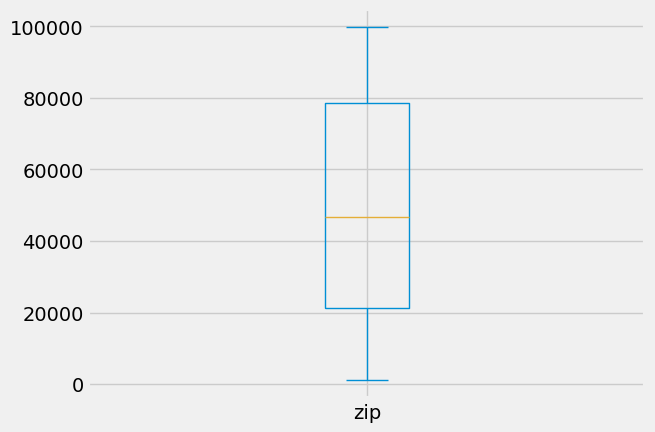

In [106]:
df['zip'].plot(kind = 'box')

As the box plot represents normal distribution, mean imputation seems to be a reasonable technique as there are no outliers. 

In [107]:
df['zip'].fillna(df['zip'].mean(), inplace = True)

**Rechecking for any null values**

In [108]:
df.isnull().sum()

id                    0
date                  0
client_id             0
card_id               0
use_chip              0
merchant_id           0
merchant_city         0
merchant_state        0
zip                   0
mcc                   0
errors                0
quarter               0
Status                0
Name                  0
Transaction_Amount    0
dtype: int64

**Interpretation:** 

All the null values are handled.

**2.2. Handling invalid values**

The 'Amount' column is suspected to have some invalid values.


In [109]:
amt = df['Transaction_Amount'].sort_values(ascending = True)
amt 

34971     -500.00
136223    -500.00
249231    -500.00
323452    -500.00
513063    -500.00
           ...   
232690    2105.76
316889    2231.37
360467    2379.03
565397    3104.71
14919     3854.44
Name: Transaction_Amount, Length: 588506, dtype: float64

In [110]:
amt_below = df[df['Transaction_Amount'] <= 0]
amt_below.shape

(34138, 15)

The rationale for interpreting the Amount column with both positive and negative values as representing credits and debits to a consumer's account is grounded in standard financial transaction conventions

1. Logical Consistency: Positive values are typically associated with deposits or credits, while negative values indicate debits or withdrawals. This assumption aligns with standard accounting practices, making the data more intuitive for analysis.

2. Enhanced Interpretability: Treating positive amounts as credits and negative amounts as debits allows for straightforward interpretations and calculations of net balances, transaction patterns, and consumer behavior.

3. Simplified Analysis and Modeling: By defining these value signs as credit and debit indicators, we streamline analytical tasks such as identifying high-expenditure consumers or tracking cash flow patterns, both of which are essential for generating actionable insights.

This assumption provides a practical framework for interpreting and working with the Amount data in a way that enhances analytical depth and maintains alignment with common financial practices.

In [111]:
amount = df['Transaction_Amount']
payment_status = []

for val in amount:
    if val < 0:
        payment_status.append('Debit')
    else:
        payment_status.append('Credit')

df['Payment_Type'] = payment_status

Treating the negative values in the feature exploration section to conduct in-depth analysis.

### 3. Improving readability

In [112]:
df.columns

Index(['id', 'date', 'client_id', 'card_id', 'use_chip', 'merchant_id',
       'merchant_city', 'merchant_state', 'zip', 'mcc', 'errors', 'quarter',
       'Status', 'Name', 'Transaction_Amount', 'Payment_Type'],
      dtype='object')

In [113]:
df.rename(columns = {"id": "ID", 'date': 'Date', 'client_id': 'CID', 'Transaction_Amount': 'Amount', 'use_chip': 'UseChip', 'merchant_id': 'MID', 'merchant_city': 'MCity', 'merchant_state': 'MState', 'zip': 'Pincode', 'mcc': 'MCC', 'errors': 'Error', 'Status': 'Fraud_Status', 'Name': 'Category'}, inplace = True)

In [114]:
df.head(3)

,ID,Date,CID,card_id,UseChip,MID,MCity,MState,Pincode,MCC,Error,quarter,Fraud_Status,Category,Amount,Payment_Type
0,7475329,2010-01-01 00:02:00,1129,102,Swipe Transaction,27092,Vista,CA,92084.0,4829,Errorless,2010Q1,No,Money Transfer,80.0,Credit
1,7475345,2010-01-01 00:32:00,1129,5492,Swipe Transaction,27092,Vista,CA,92084.0,4829,Errorless,2010Q1,No,Money Transfer,100.0,Credit
2,7475360,2010-01-01 00:49:00,652,4293,Swipe Transaction,74624,East Hartford,CT,6108.0,5411,Errorless,2010Q1,No,"Grocery Stores, Supermarkets",2.4,Credit


## Feature Engineering for Analysis

1. Breaking the date variable

In [115]:
df['Date'] = pd.to_datetime(df['Date'])

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month

## Dataset for Analysis

In [116]:
df.head(3)

,ID,Date,CID,card_id,UseChip,MID,MCity,MState,Pincode,MCC,Error,quarter,Fraud_Status,Category,Amount,Payment_Type,Day,Month
0,7475329,2010-01-01 00:02:00,1129,102,Swipe Transaction,27092,Vista,CA,92084.0,4829,Errorless,2010Q1,No,Money Transfer,80.0,Credit,1,1
1,7475345,2010-01-01 00:32:00,1129,5492,Swipe Transaction,27092,Vista,CA,92084.0,4829,Errorless,2010Q1,No,Money Transfer,100.0,Credit,1,1
2,7475360,2010-01-01 00:49:00,652,4293,Swipe Transaction,74624,East Hartford,CT,6108.0,5411,Errorless,2010Q1,No,"Grocery Stores, Supermarkets",2.4,Credit,1,1


## Affinity analysis
It has been realized that inside the dataset "Goods_receipt" there are the transactions that the company has made in the years x - x , and moreover it is the only dataset that shows us the type of good or service (GR Internal Code) that is purchased. Then according to the theory of Affinity Analysis, also known as Market Basket Analysis, it extracts "accidental" patterns of purchases that may influence the purchase of another product or service. In fact, in order to extract this pattern, we have observed that more transactions under the same ['ID purchase order'] were distinguished on the basis of the type of good or service purchased.


In [117]:
# Ensure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'])
print(df.shape)

# Sort by date

df = df.sort_values('Date')

last_date = df['Date'].max()
cutoff_date = last_date - pd.DateOffset(months=6)

train = df[df['Date'] < cutoff_date].copy()
test  = df[df['Date'] >= cutoff_date].copy()


(588506, 18)


We observed the most frequent consumption categories, from which we can infer potential consumption relationships between categories.

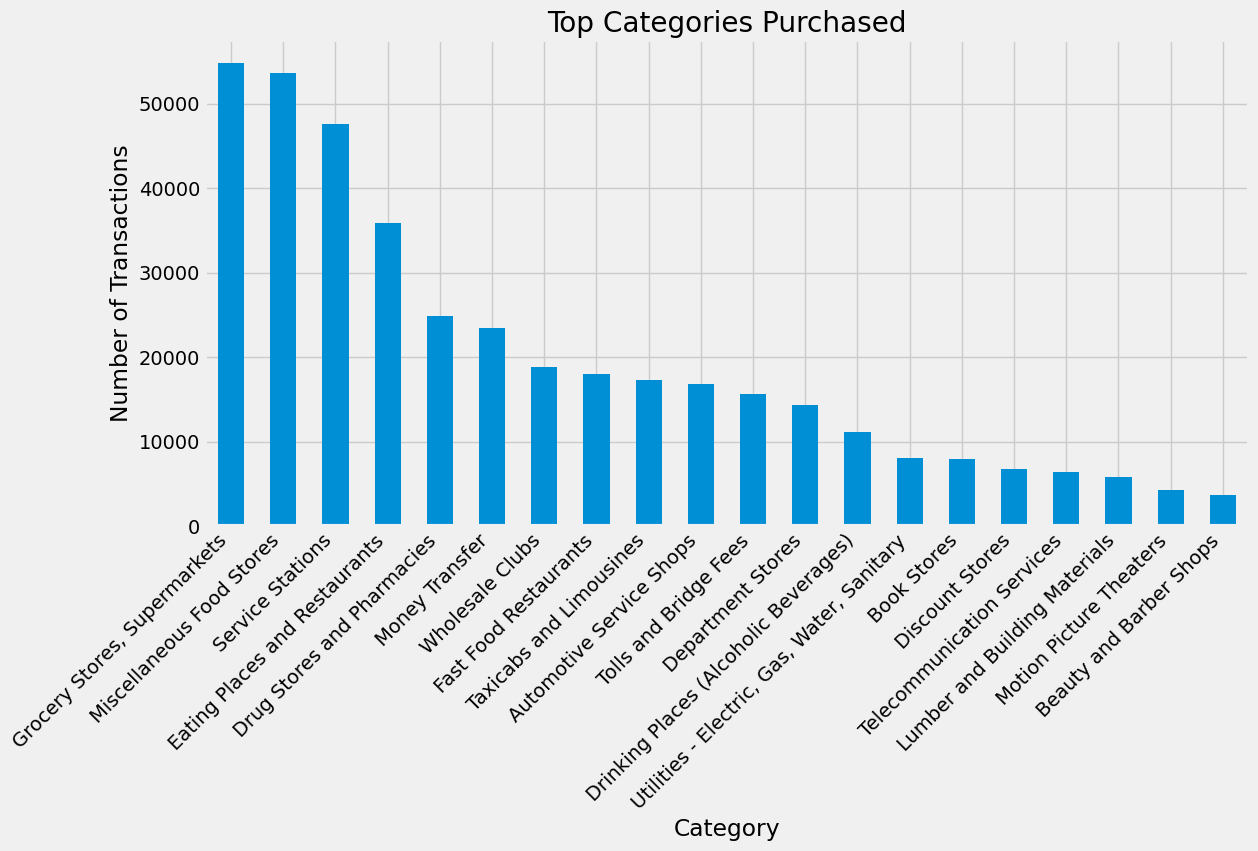

In [118]:
# Plot the top categories
plt.figure(figsize=(12,6))
category_counts.head(20).plot(kind='bar')  # Top 20 categories
plt.title('Top Categories Purchased')
plt.ylabel('Number of Transactions')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.show()


We grouped the data by quarters with the aim of aggregating information and reducing granularity.

In [119]:
# Add 'quarter' column to mark the quarter of each transaction
train['month'] = train['Date'].dt.to_period('M')

# First, create a column to indicate purchase = 1
train['Purchased'] = 1

train.head()


,ID,Date,CID,card_id,UseChip,MID,MCity,MState,Pincode,MCC,Error,quarter,Fraud_Status,Category,Amount,Payment_Type,Day,Month,month,Purchased
0,7475329,2010-01-01 00:02:00,1129,102,Swipe Transaction,27092,Vista,CA,92084.0,4829,Errorless,2010Q1,No,Money Transfer,80.00,Credit,1,1,2010-01,1
1,7475345,2010-01-01 00:32:00,1129,5492,Swipe Transaction,27092,Vista,CA,92084.0,4829,Errorless,2010Q1,No,Money Transfer,100.00,Credit,1,1,2010-01,1
2,7475360,2010-01-01 00:49:00,652,4293,Swipe Transaction,74624,East Hartford,CT,6108.0,5411,Errorless,2010Q1,No,"Grocery Stores, Supermarkets",2.40,Credit,1,1,2010-01,1
3,7475400,2010-01-01 01:54:00,597,4540,Swipe Transaction,66541,San Francisco,CA,94131.0,5300,Errorless,2010Q1,No,Wholesale Clubs,14.20,Credit,1,1,2010-01,1
4,7475540,2010-01-01 05:38:00,1769,43,Swipe Transaction,86438,Manahawkin,NJ,8050.0,5499,Errorless,2010Q1,No,Miscellaneous Food Stores,0.18,Credit,1,1,2010-01,1


In affinity analysis, the quantity of each item bought is not strictly important. What is important is if the firm has bought or not. So we encoded the table above into binary data that shows whether an item is bought (1) or not (0).

In [120]:
customer_monthly_category = train.pivot_table(
    index=['CID', 'month'],
    columns='Category',
    values='Purchased',
    aggfunc='max',
    fill_value=0
).astype('int8')

threshold_omnipresent = 0.85
frequencies = (customer_monthly_category > 0).mean()
cols_to_keep = frequencies[frequencies < threshold_omnipresent].index
customer_monthly_filtered = customer_monthly_category[cols_to_keep]
basket_bool = (customer_monthly_filtered > 0)
# Filtro de cestas con ≥ 2 ítems (requisito para reglas de asociación)
mask_ge2 = basket_bool.sum(axis=1) >= 2
basket_filter_agg = basket_bool[mask_ge2].copy()
basket_filter_agg = basket_filter_agg.astype(bool)

# Lag por cliente (elimina future bias dentro del MBA inter-quarter)
customer_lag = customer_monthly_filtered.groupby(level=0).shift(1).fillna(0).astype(bool)


inter_month = customer_lag.join(
    customer_monthly_filtered > 0,
    how='inner',
    lsuffix='_prev_month',
    rsuffix='_current_month'
)






in the following step, we are uncovering the association between 2 or more items that is bought according to historical data. We are filtering out when the association in purchasing patterns even though the persone buy only one item.

In [121]:
# Filter customers/quarters with at least 2 categories purchased


mask_inter_ge2 = inter_month.sum(axis=1) >= 2
basket_inter_final = inter_month[mask_inter_ge2]
basket_filter_agg_lag = customer_lag[(customer_lag > 0).sum(axis=1) >= 2]
basket_filter_agg_inter = inter_month[(inter_month > 0).sum(axis=1) >= 2]
basket_filter_agg_lag = basket_filter_agg_lag.astype(bool)
basket_filter_agg_inter = basket_filter_agg_inter.astype(bool)



## Apriori Algorithm
Apriori algorithm is a classic algorithm that is useful to mine frequent itemsets and relevant association rules. Usually this algorithm works well on database containing a large number of transactions.

In [122]:
from mlxtend.frequent_patterns import fpgrowth

In [123]:
print(basket_filter_agg.shape)
print(basket_filter_agg_lag.shape)
print(basket_filter_agg_inter.shape)    

(9405, 104)
(9317, 104)
(9405, 208)


In [124]:
def process_frequent_itemsets(df, min_sup=0.5):
    if df.empty:
        return pd.DataFrame()
    
    # FP-Growth es más rápido que Apriori para datos densos
    fi = fpgrowth(df, min_support=min_sup, use_colnames=True, max_len=2)
    fi = fi.sort_values('support', ascending=False).reset_index(drop=True)
    
    # Tu lógica de columnas adicionales
    fi['length'] = fi['itemsets'].apply(lambda x: len(x))
    total_tx = len(df)
    fi['count'] = (fi['support'] * total_tx).astype(int)
    
    return fi

# 5. Ejecución y Resultados
frequent_itemsets_plus = process_frequent_itemsets(basket_filter_agg)
frequent_itemsets_plus_lag = process_frequent_itemsets(basket_filter_agg_lag)
frequent_itemsets_inter = process_frequent_itemsets(basket_filter_agg_inter)

# Visualización (Ejemplo)
print("--- Frequent Itemsets Actuales (Mensual) ---")
print(frequent_itemsets_plus[['itemsets', 'support', 'count', 'length']].head())

print("\n--- Frequent Itemsets Inter-Mensuales (Lag + Current) ---")
print(frequent_itemsets_inter[['itemsets', 'support', 'count', 'length']].head())

--- Frequent Itemsets Actuales (Mensual) ---
                          itemsets   support  count  length
0      (Miscellaneous Food Stores)  0.846039   7957       1
1  (Eating Places and Restaurants)  0.807549   7595       1
2              (Department Stores)  0.789899   7429       1
3       (Automotive Service Shops)  0.785965   7392       1
4          (Fast Food Restaurants)  0.688145   6472       1

--- Frequent Itemsets Inter-Mensuales (Lag + Current) ---
                                        itemsets   support  count  length
0      (Miscellaneous Food Stores_current_month)  0.846039   7957       1
1         (Miscellaneous Food Stores_prev_month)  0.837533   7877       1
2  (Eating Places and Restaurants_current_month)  0.807549   7595       1
3     (Eating Places and Restaurants_prev_month)  0.800106   7525       1
4              (Department Stores_current_month)  0.789899   7429       1


In [125]:
# Number of total transactions used in apriori
total_transactions = len(frequent_itemsets_plus)

# Create a new column with the absolute count
frequent_itemsets_plus['count'] = frequent_itemsets_plus['support'] * total_transactions

# Convert to integer if you want
frequent_itemsets_plus['count'] = frequent_itemsets_plus['count'].astype(int)

# See the results
print(frequent_itemsets_plus[['itemsets', 'support', 'count']])

                                             itemsets   support  count
0                         (Miscellaneous Food Stores)  0.846039     25
1                     (Eating Places and Restaurants)  0.807549     24
2                                 (Department Stores)  0.789899     23
3                          (Automotive Service Shops)  0.785965     23
4                             (Fast Food Restaurants)  0.688145     20
5   (Eating Places and Restaurants, Miscellaneous ...  0.676555     20
6      (Miscellaneous Food Stores, Department Stores)  0.666879     20
7   (Miscellaneous Food Stores, Automotive Service...  0.665391     19
8   (Eating Places and Restaurants, Fast Food Rest...  0.649867     19
9   (Eating Places and Restaurants, Department Sto...  0.644976     19
10  (Eating Places and Restaurants, Automotive Ser...  0.641574     19
11                       (Telecommunication Services)  0.640191     19
12       (Utilities - Electric, Gas, Water, Sanitary)  0.635513     19
13    

## Association rules
Association rules has been carried out in order to extract information and discover knowledge about which items that more effective sold together and analyse numerically metrics associated with it. So we can determine which type of spend it's less flexible and will be more present in buying moment

In [126]:
from mlxtend.frequent_patterns import association_rules

In [127]:
rules_inter = association_rules(
    frequent_itemsets_inter,
    metric='lift',
    min_threshold=1.1
).sort_values('lift', ascending=False).reset_index(drop=True)

rules_inter


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Fast Food Restaurants_prev_month),(Fast Food Restaurants_current_month),0.681978,0.688145,0.563636,0.826473,1.201017,1.0,0.094337,1.797161,0.526291,0.698879,0.443567,0.822770
1,(Fast Food Restaurants_current_month),(Fast Food Restaurants_prev_month),0.688145,0.681978,0.563636,0.819067,1.201017,1.0,0.094337,1.757678,0.536698,0.698879,0.431067,0.822770
2,(Eating Places and Restaurants_prev_month),(Fast Food Restaurants_prev_month),0.800106,0.681978,0.643806,0.804651,1.179879,1.0,0.098152,1.627971,0.762683,0.768011,0.385739,0.874340
3,(Fast Food Restaurants_prev_month),(Eating Places and Restaurants_prev_month),0.681978,0.800106,0.643806,0.944029,1.179879,1.0,0.098152,3.571359,0.479386,0.768011,0.719995,0.874340
4,(Eating Places and Restaurants_current_month),(Fast Food Restaurants_current_month),0.807549,0.688145,0.649867,0.804740,1.169434,1.0,0.094156,1.597129,0.752846,0.768322,0.373876,0.874558
5,(Fast Food Restaurants_current_month),(Eating Places and Restaurants_current_month),0.688145,0.807549,0.649867,0.944376,1.169434,1.0,0.094156,3.459838,0.464593,0.768322,0.710969,0.874558
6,(Fast Food Restaurants_current_month),(Eating Places and Restaurants_prev_month),0.688145,0.800106,0.641786,0.932633,1.165636,1.0,0.091197,2.967229,0.455658,0.758196,0.662985,0.867380
7,(Eating Places and Restaurants_prev_month),(Fast Food Restaurants_current_month),0.800106,0.688145,0.641786,0.802126,1.165636,1.0,0.091197,1.576032,0.710875,0.758196,0.365495,0.867380
8,(Fast Food Restaurants_prev_month),(Eating Places and Restaurants_current_month),0.681978,0.807549,0.641574,0.940755,1.164950,1.0,0.090843,3.248367,0.445234,0.756614,0.692153,0.867612
9,(Eating Places and Restaurants_current_month),(Fast Food Restaurants_prev_month),0.807549,0.681978,0.641574,0.794470,1.164950,1.0,0.090843,1.547328,0.735742,0.756614,0.353725,0.867612


Based on the inter-quarter affinity analysis of individual transaction data, we observed that several purchase categories exhibit strong sequential patterns between consecutive quarters. For example:

The lift values above 1 suggest that these sequential associations are stronger than random, highlighting meaningful inter-quarter dependencies in consumer spending. These insights reveal which past behaviors are most indicative of future purchases, which can be used for forecasting, targeted recommendations, or constructing lagged regressors for predictive models. Aggregating data by quarters helps emphasize consistent patterns, while less frequent associations may require adjusted support thresholds to detect.

## Time series forecasting Blocked Invoices

Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet is robust to missing data and shifts in the trend, and typically handles outliers well.

In [128]:
from prophet import Prophet
from prophet.plot import plot_plotly
from prophet.diagnostics import cross_validation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

The Prophet library expects as input a dataframe with one column containing the time information, and another column containing the metric that we wish to forecast.



To better understand spending behavior, we group expense categories into clusters. Using the results from the affinity analysis, categories that tend to occur together—such as eating places and fast food restaurants, or miscellaneous food stores and service stations—are combined into clusters. For each cluster, we aggregate the expenses by quarter, creating a simplified and interpretable dataset. These clusters not only reduce the complexity of the raw transaction data but can also be used as features or regressors in forecasting models like Prophet, improving both prediction accuracy and insight into spending patterns.



--- Generating Automatic Feature Map ---
Total features mapped: 2


22:38:52 - cmdstanpy - INFO - Chain [1] start processing
22:38:52 - cmdstanpy - INFO - Chain [1] done processing
22:38:52 - cmdstanpy - INFO - Chain [1] start processing



--- Regressor Cleanup ---
Total regressors generated: 4
Active regressors (with data): 2
Removed regressors (all zeros): ['fast_food_restaurants_debit_lag1', 'eating_places_restaurants_debit_lag1']


22:38:52 - cmdstanpy - INFO - Chain [1] done processing



--- Monthly Evaluation Results (Optimized + Filtered) ---
Active Features Used: ['eating_places_restaurants_credit_lag1', 'fast_food_restaurants_credit_lag1']
                   Model          RMSE      MAPE
0               Baseline  12263.475530  5.153495
1  Extended (Auto-Rules)  13208.035089  5.555111


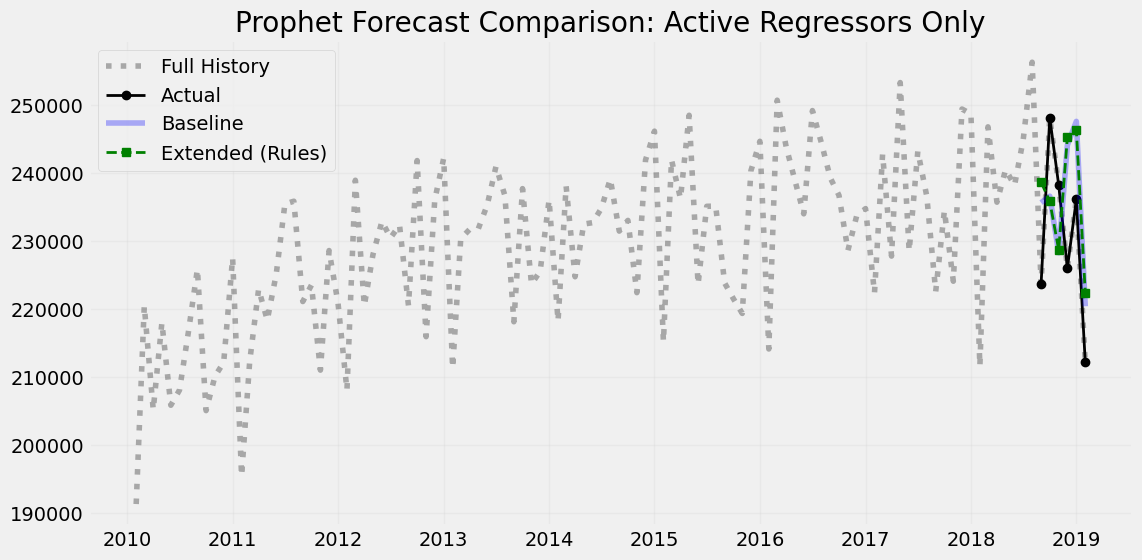

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# === 1. Preprocessing & Date Setup ===
# Creating a copy of the training data
train_fg = train.copy()

# Date conversion and monthly timestamp alignment
train_fg['Date'] = pd.to_datetime(train_fg['Date'])
train_fg['month'] = train_fg['Date'].dt.to_period('M')
train_fg['ds'] = train_fg['month'].dt.to_timestamp(how='start')

# Normalize categories and ensure Amount is numeric
train_fg['Category_norm'] = train_fg['Category'].astype(str).str.strip().str.lower()
train_fg['Amount'] = pd.to_numeric(train_fg['Amount'])

# === 2. Logic for Expenses and Income using Payment_Type ===
# We use the absolute value for regressors to measure the "volume" of activity
train_fg['abs_amount'] = train_fg['Amount'].abs()

# Conditional logic based on 'Payment_Type' provided in the dataset
# This ensures correct classification regardless of the Amount's mathematical sign
train_fg['expense_val'] = np.where(train_fg['Payment_Type'] == 'Debit', train_fg['abs_amount'], 0.0)
train_fg['income_val']  = np.where(train_fg['Payment_Type'] == 'Credit', train_fg['abs_amount'], 0.0)

# === 3. Automated Feature Grouping (Association Rules) ===

def parse_rule_item(item_set):
    """Helper to extract a single item from a frozenset or string set."""
    if isinstance(item_set, (frozenset, set)):
        return list(item_set)[0]
    elif isinstance(item_set, str):
        clean = item_set.replace("frozenset({", "").replace("})", "").replace("'", "").replace('"', "")
        return clean.split(',')[0].strip()
    return str(item_set)

feature_group_map = {}

print("--- Generating Automatic Feature Map ---")

for idx, row in rules_inter.iterrows():
    # Filter by lift to ensure we only use meaningful associations
    if row['lift'] < 1.1: continue
        
    ant_raw = parse_rule_item(row['antecedents']).lower()
    con_raw = parse_rule_item(row['consequents']).lower()
    
    base_cat_name = None

    # Detect temporal patterns (Previous Month -> Current Month)
    if '_prev_month' in ant_raw and '_current_month' in con_raw:
        base_cat_name = ant_raw.replace('_prev_month', '').strip()
    elif '_current_month' in ant_raw and '_prev_month' in con_raw:
        base_cat_name = con_raw.replace('_prev_month', '').strip()
        
    if base_cat_name:
        key_norm = base_cat_name
        # Clean the name for use as a dataframe column
        value_group = base_cat_name.replace(' ', '_').replace('and', '').replace('__', '_')
        feature_group_map[key_norm] = value_group

print(f"Total features mapped: {len(feature_group_map)}")

# Apply the mapping to the dataframe
train_fg['feature_group'] = train_fg['Category_norm'].map(feature_group_map).fillna('other')

# === 4. Dynamic Aggregation (Monthly) ===

# Group expenses and income by month and category group
expenses_group = train_fg.groupby(['ds', 'feature_group'])['expense_val'].sum().unstack().fillna(0.0)
income_group   = train_fg.groupby(['ds', 'feature_group'])['income_val'].sum().unstack().fillna(0.0)

target_groups = [g for g in list(set(feature_group_map.values())) if g != 'other']

# Ensure all target columns exist even if they have no values in some months
for group in target_groups:
    if group not in expenses_group.columns: expenses_group[group] = 0.0
    if group not in income_group.columns: income_group[group] = 0.0

# Add suffixes to distinguish between Debits and Credits
expenses_final = expenses_group[target_groups].add_suffix('_debit')
income_final   = income_group[target_groups].add_suffix('_credit')

# Target Variable 'y' (The actual Monthly Net Total)
agg_month_fg = train_fg.groupby('ds', as_index=False).agg(y=('Amount', 'sum'))

# Merge everything into a master monthly dataframe
df_month = (
    agg_month_fg
    .set_index('ds')
    .join(expenses_final, how='left')
    .join(income_final,   how='left')
    .fillna(0.0)
    .sort_index()
)

# === 5. Create Monthly Lags ===
# We use Lag-1 (previous month) as the regressor to predict the current month
reg_cols = list(expenses_final.columns) + list(income_final.columns)
lag_reg_cols = []

for col in reg_cols:
    lag_col_name = col + '_lag1'
    df_month[lag_col_name] = df_month[col].shift(1)
    lag_reg_cols.append(lag_col_name)

# --- CRITICAL CLEANUP ---
# 1. Drop the first row (which has NaNs due to shifting)
df_month = df_month.dropna(subset=lag_reg_cols)
# 2. Drop the last month if it is incomplete (avoids skewing results)
df_month = df_month[df_month.index < df_month.index.max()]
# 3. Reset index to move 'ds' back to a column
df_month = df_month.reset_index()

# === 5.5. FILTERING NULL REGRESSORS ===
# Identify columns that actually contain data (sum of absolute values > 0)
active_lag_reg_cols = [col for col in lag_reg_cols if df_month[col].abs().sum() > 0]

print(f"\n--- Regressor Cleanup ---")
print(f"Total regressors generated: {len(lag_reg_cols)}")
print(f"Active regressors (with data): {len(active_lag_reg_cols)}")
print(f"Removed regressors (all zeros): {list(set(lag_reg_cols) - set(active_lag_reg_cols))}")

# === 6. Evaluation: Prophet (Monthly Config) ===

# Splitting data (last 6 months for testing)
n_test = 6
df_month = df_month.sort_values('ds').reset_index(drop=True)

train_df = df_month.iloc[:-n_test].copy()
test_df  = df_month.iloc[-n_test:].copy()

# --- 6.1. Baseline Model ---
# Standard Prophet with yearly seasonality
base_model = Prophet(growth='linear', seasonality_mode='multiplicative', yearly_seasonality=True)
base_model.fit(train_df[['ds', 'y']])
y_pred_base = base_model.predict(test_df[['ds']])['yhat'].values

# --- 6.2. Extended Model (Auto-Rules with Filter) ---
ext_model = Prophet(growth='linear', seasonality_mode='multiplicative', yearly_seasonality=True)

if active_lag_reg_cols:
    for col in active_lag_reg_cols:
        # prior_scale=10.0 allows the model to give more weight to external regressors
        ext_model.add_regressor(col, prior_scale=10.0, mode='multiplicative')
    
    ext_model.fit(train_df[['ds', 'y'] + active_lag_reg_cols])
    y_pred_ext = ext_model.predict(test_df[['ds'] + active_lag_reg_cols])['yhat'].values
else:
    print("⚠️ No active regressors found. Extended model will match Baseline.")
    y_pred_ext = y_pred_base

# === 7. Results & Visualization ===

y_true = test_df['y'].values

def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))
def mape(y_true, y_pred): return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("\n--- Monthly Evaluation Results (Optimized + Filtered) ---")
print(f"Active Features Used: {active_lag_reg_cols}")
results = pd.DataFrame({
    'Model': ['Baseline', 'Extended (Auto-Rules)'],
    'RMSE': [rmse(y_true, y_pred_base), rmse(y_true, y_pred_ext)],
    'MAPE': [mape(y_true, y_pred_base), mape(y_true, y_pred_ext)]
})
print(results)

# Plotting the forecast
plt.figure(figsize=(12, 6))
plt.plot(df_month['ds'], df_month['y'], 'k:', alpha=0.3, label='Full History')
plt.plot(test_df['ds'], y_true, 'k-o', lw=2, label='Actual')
plt.plot(test_df['ds'], y_pred_base, color='blue', lw=4, alpha=0.3, label='Baseline')
plt.plot(test_df['ds'], y_pred_ext, color='green', linestyle='--', lw=2, marker='s', label='Extended (Rules)')
plt.title('Prophet Forecast Comparison: Active Regressors Only')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [141]:
from prophet.utilities import regressor_coefficients
coeffs = regressor_coefficients(ext_model)
print("\n--- Regressor Coefficients ---")
print(coeffs)


--- Regressor Coefficients ---
                               regressor  regressor_mode        center  \
0  eating_places_restaurants_credit_lag1  multiplicative  11102.063301   
1      fast_food_restaurants_credit_lag1  multiplicative   5472.946117   

   coef_lower      coef  coef_upper  
0   -0.000001 -0.000001   -0.000001  
1    0.000014  0.000014    0.000014  


# Conclusion and Model Performance Analysis

The evaluation results demonstrate that the **Extended Model (Auto-Rules)** performs almost identically to the **Baseline Model**. In fact, the Root Mean Square Error (**RMSE**) increased slightly from **12,263** to **13,208**, and the **MAPE** rose from **5.15%** to **5.55%**. This indicates that the current association rule regressors are introducing "noise" rather than providing predictive value.

## 1. Root Cause Analysis

### Scale Disparity and Signal-to-Noise Ratio
The primary reason for this behavior is the **significant scale disparity**. The total monthly expenditure (target variable $y$) fluctuates around **240,000**, whereas the specific regressors identified (*Eating Places* and *Fast Food*) represent a very small percentage of this total (approx. 7%). 



### Mathematical Insignificance (Coefficients)
The **Regressor Coefficients** found by the model ($1.4 \times 10^{-5}$) are effectively zero. This confirms that for every dollar spent in these categories, the impact on the forecast is negligible. Prophet's internal L1 regularization naturally "shrinks" these coefficients to zero because it finds that their monthly fluctuations do not reliably correlate with the total volume fluctuations.

### Seasonality Overlap
Prophet's internal **Yearly Seasonality** terms already capture seasonal spending habits (such as eating out more during holidays). Because the external regressors follow a similar seasonal curve, they provide redundant information. The baseline model has already "accounted" for this movement, leaving nothing for the extra regressors to explain.

---

## 2. Strategic Recommendations for Future Iterations

To move beyond the baseline and achieve a more robust forecast, the following strategic pivots are recommended:

### A. Identification of "Heavy" Regressors
Instead of focusing on niche categories, the **Association Rules** should be tuned to find "High-Volume" clusters. 
* **Target:** Identify categories or groups that represent at least **20-30% of the total monthly amount**. 
* **Action:** Filter the affinity analysis for categories related to fixed costs (Rent, Mortgages) and major income sources (Salary).

### B. Advanced Feature Engineering
Since raw amounts are being ignored due to scale disparity, we should transform the features:
* **Standardization:** Apply `StandardScaler` to the regressors so the model evaluates them in terms of *Standard Deviations* rather than raw dollars.
* **Momentum (Growth Rate):** Use the **percentage change** month-over-month instead of the absolute amount.



### C. Temporal Sensitivity
The current **Lag-1** approach assumes a delayed financial impact. 
* **Action:** Test a "Now-casting" model using **Contemporaneous Data** to determine if there is a stronger same-month correlation. If a relationship exists there, we can then look for leading indicators to project those values forward.Ç